In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

Import Dataset

In [3]:
df = pd.read_csv('../data/raw/malaysia_house_price_data_2025.csv')
df.head()

,Township,Area,State,Tenure,Type,Median_Price,Median_PSF,Transactions
0,SCIENTEX SUNGAI DUA,Tasek Gelugor,Penang,Freehold,Terrace House,331800.0,304.0,593
1,BANDAR PUTRA,Kulai,Johor,Freehold,"Cluster House, Terrace House",590900.0,322.0,519
2,TAMAN LAGENDA TROPIKA TAPAH,Chenderiang,Perak,Freehold,Terrace House,229954.0,130.0,414
3,SCIENTEX JASIN MUTIARA,Bemban,Melaka,Freehold,Terrace House,255600.0,218.0,391
4,TAMAN LAGENDA AMAN,Tapah,Perak,Leasehold,Terrace House,219300.0,168.0,363


Info check

In [9]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Township      2000 non-null   str    
 1   Area          2000 non-null   str    
 2   State         2000 non-null   str    
 3   Tenure        2000 non-null   str    
 4   Type          2000 non-null   str    
 5   Median_Price  2000 non-null   float64
 6   Median_PSF    2000 non-null   float64
 7   Transactions  2000 non-null   int64  
dtypes: float64(2), int64(1), str(5)
memory usage: 236.7 KB
None


Dataset Shape

In [8]:
print(df.shape)

(2000, 8)


Data type

In [7]:
print(df.dtypes)

Township            str
Area                str
State               str
Tenure              str
Type                str
Median_Price    float64
Median_PSF      float64
Transactions      int64
dtype: object


Target Distribution

In [12]:
print(df["Transactions"].value_counts())

Transactions
11    242
12    169
13    135
14    134
10    114
     ... 
86      1
84      1
77      1
65      1
61      1
Name: count, Length: 142, dtype: int64


Numerical Summary

In [13]:
print(df.describe())

       Median_Price   Median_PSF  Transactions
count  2.000000e+03  2000.000000   2000.000000
mean   4.906854e+05   328.862500     28.091500
std    4.686322e+05   193.281739     37.702385
min    2.704900e+04    38.000000     10.000000
25%    2.699500e+05   201.000000     12.000000
50%    3.900000e+05   293.000000     16.000000
75%    5.735000e+05   412.000000     28.000000
max    1.142050e+07  3017.000000    593.000000


Unique value of Every Categorical Features

In [16]:
for col in ["Township", "Area", "State", "Tenure", "Type"]:
	print(col)
	print(df[col].value_counts())

Township
Township
TAMAN MAWAR                   4
TAMAN DELIMA                  4
TAMAN BUNGA RAYA              3
TAMAN PUTERI                  3
BANDAR SERI BOTANI            3
                             ..
TAMAN ANDALAS JAYA            1
TAMAN ANJUNG BERCHAM MEGAH    1
TAMAN PUNCAK JELAPANG MAJU    1
TAMAN TIONG UNG SIEW          1
TAMAN DESA RISHAH INDAH       1
Name: count, Length: 1946, dtype: int64
Area
Area
Ipoh                 67
Johor Bahru          51
Klang                50
Skudai               45
Sungai Petani        43
                     ..
Sungai Besar          1
Gerik                 1
Sri Aman              1
Kuala Sungai Baru     1
Machang               1
Name: count, Length: 303, dtype: int64
State
State
Selangor           545
Johor              377
Perak              194
Penang             187
Kuala Lumpur       176
Negeri Sembilan    135
Kedah              103
Melaka              98
Pahang              71
Sarawak             54
Sabah               40
Terengganu  

Check for data leakage

In [18]:
print(df[["Median_Price", "Median_PSF", "Transactions"]].corr(numeric_only=True))

              Median_Price  Median_PSF  Transactions
Median_Price      1.000000    0.746647       0.00900
Median_PSF        0.746647    1.000000      -0.01153
Transactions      0.009000   -0.011530       1.00000


Plot a Scatter Plot

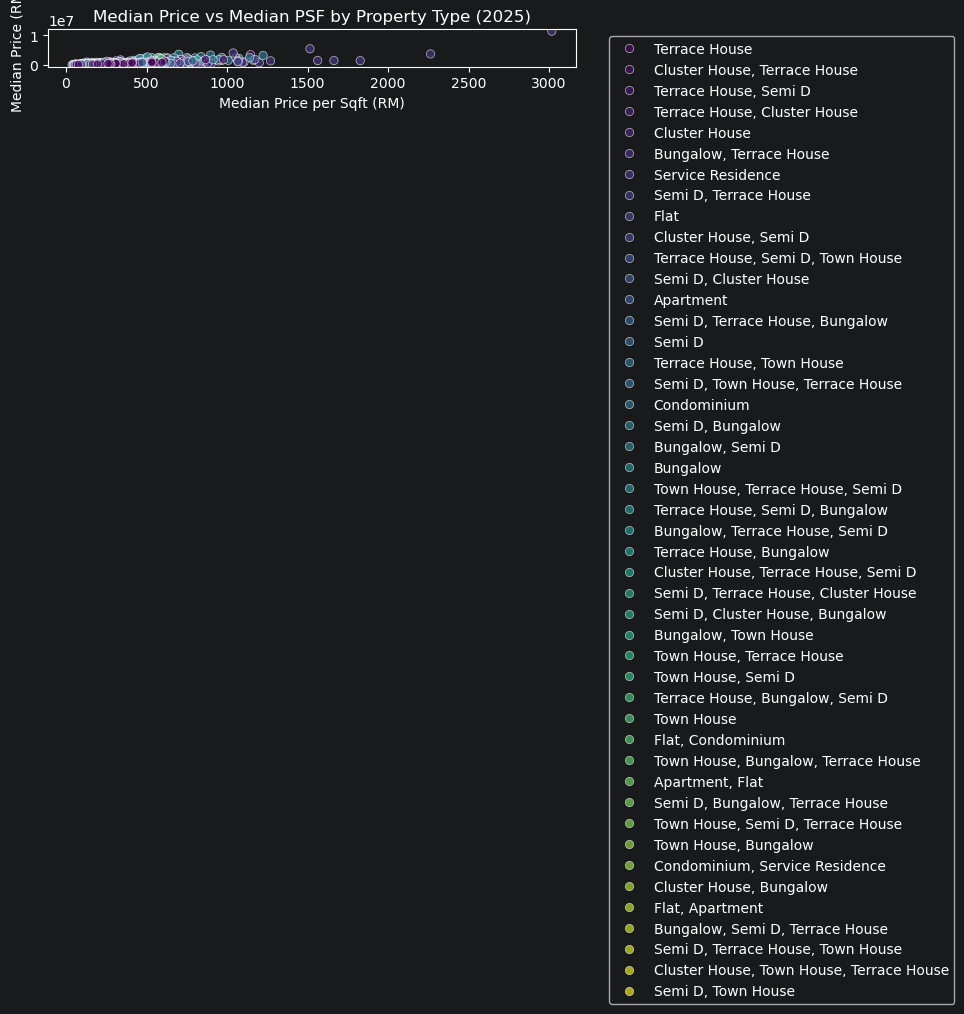

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Median_PSF",
    y="Median_Price",
    hue="Type",
    alpha=0.7,
    palette="viridis"
)
plt.title("Median Price vs Median PSF by Property Type (2025)")
plt.xlabel("Median Price per Sqft (RM)")
plt.ylabel("Median Price (RM)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

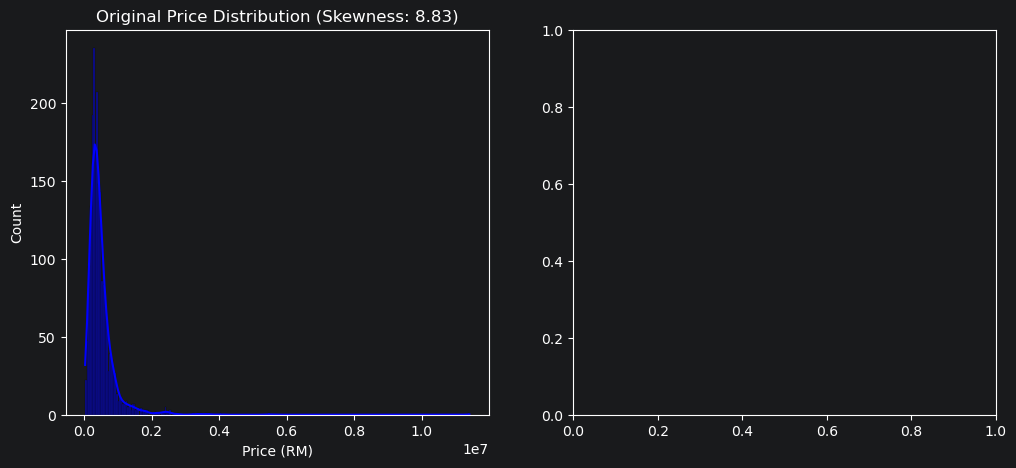

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["Median_Price"], kde=True, color="blue")
plt.title(f"Original Price Distribution (Skewness: {df['Median_Price'].skew():.2f})")
plt.xlabel("Price (RM)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["Median_Price"]), kde=True, color="green")
plt.title(f"Log-transformed Price Distribution (Skewness: {np.log1p(df['Median_Price']).skew():.2f})")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()